
ARBITRARY ENTANGLED STATE CIRCUIT
     ┌───────────┐     
q_0: ┤ Ry(5π/14) ├──■──
     └───────────┘┌─┴─┐
q_1: ─────────────┤ X ├
                  └───┘

STATEVECTOR
Statevector([0.8467242 +0.j, 0.        +0.j, 0.        +0.j,
             0.53203208+0.j],
            dims=(2, 2))

BASIS STATE PROBABILITIES
|00> : 0.716942
|11> : 0.283058

NORMALIZATION CHECK
Total probability = 1.000000

THEORETICAL VALUES
P(00) = 0.716942
P(11) = 0.283058


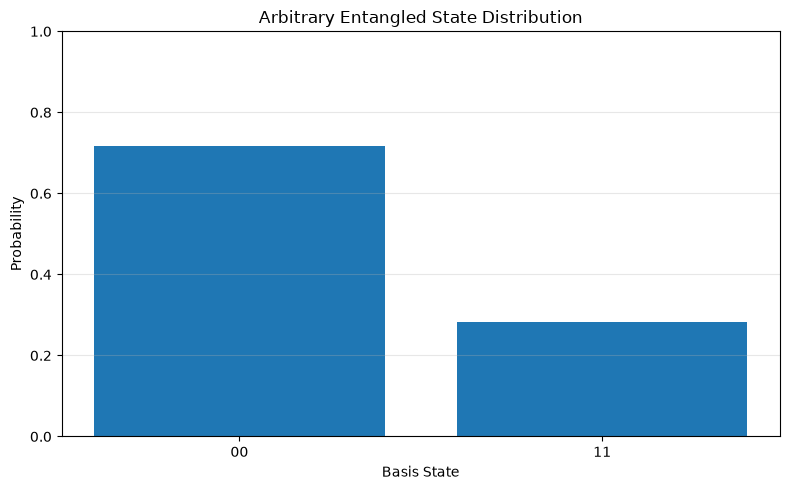

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

theta = np.pi / 2.8

qc = QuantumCircuit(2)

qc.ry(theta, 0)
qc.cx(0, 1)

print("\nARBITRARY ENTANGLED STATE CIRCUIT")
print("=" * 65)
print(qc.draw())

state = Statevector.from_instruction(qc)

print("\nSTATEVECTOR")
print("=" * 65)
print(state)

probabilities = state.probabilities_dict()

print("\nBASIS STATE PROBABILITIES")
print("=" * 65)

states = []
values = []

for basis_state, probability in probabilities.items():

    if probability > 1e-10:
        states.append(basis_state)
        values.append(probability)
        print(f"|{basis_state}> : {probability:.6f}")

print("\nNORMALIZATION CHECK")
print("=" * 65)

print(f"Total probability = {sum(values):.6f}")

theoretical_00 = np.cos(theta / 2) ** 2
theoretical_11 = np.sin(theta / 2) ** 2

print("\nTHEORETICAL VALUES")
print("=" * 65)
print(f"P(00) = {theoretical_00:.6f}")
print(f"P(11) = {theoretical_11:.6f}")

plt.figure(figsize=(8, 5))

plt.bar(states, values)

plt.xlabel("Basis State")
plt.ylabel("Probability")
plt.title("Arbitrary Entangled State Distribution")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()